# This is a sample Jupyter Notebook

Below is an implementation of the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
# load
from sklearn.model_selection import train_test_split

train_path = ("mitbih_train.csv")
test_path = ("mitbih_test.csv")

train = pd.read_csv(train_path, header=None)
for i in range(train.shape[1]):
    train = train.rename(columns={train.columns[i]: str(i)})
train = train.rename(columns={train.columns[-1]: "label"})

test = pd.read_csv(test_path, header=None)
for i in range(test.shape[1]):
    test = test.rename(columns={test.columns[i]: str(i)})
test = test.rename(columns={test.columns[-1]: "label"})

# distribution
x_train_all = train.drop("label", axis=1)
y_train_all = train["label"]

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all, y_train_all,
    test_size=0.2,
    random_state=1,
    stratify=y_train_all # dla klasyfikacji
)

x_test = test.drop("label", axis=1)
y_test = test["label"]

print(train.head())

print("train shape:", train.shape)
print("test shape :", test.shape)

          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  label  
0  0.0    0.0  
1  0.0    0.0  
2  0.0    0.0  
3  0

In [3]:
x_train.info()

procent_null = 100 * x_train.isnull().sum().sum() / x_train.size
print(f"Procent brakujacych danych: {procent_null:.2f}%")

<class 'pandas.core.frame.DataFrame'>
Index: 70043 entries, 4019 to 78219
Columns: 187 entries, 0 to 186
dtypes: float64(187)
memory usage: 100.5 MB
Procent brakujacych danych: 0.00%


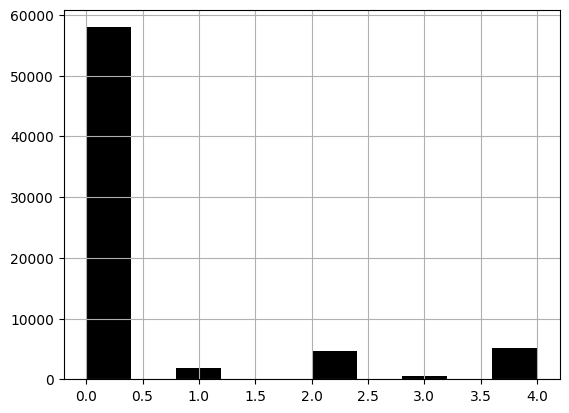

In [4]:
y_train.hist(bins = 10, color='black')
plt.show()

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

proc_pipeline = Pipeline(steps=[
    ('std_scaler', StandardScaler()),
])

column_transformer = ColumnTransformer([
    ('num', proc_pipeline, x_train.columns),
])

preprocessor = Pipeline(steps=[
    ('column_transformer', column_transformer),
])

x_ready = preprocessor.fit_transform(x_train)
print(x_ready)

[[ 0.0897241   0.05878623 -1.25249221 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.45486063  0.45814731  0.65514626 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.45486063 -0.09558988 -0.13297176 ... -0.09168416 -0.08887797
  -0.08729329]
 ...
 [ 0.01591676  0.59744286  0.60739866 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.33975433 -0.07919169 -1.00109742 ... -0.09168416 -0.08887797
  -0.08729329]
 [-2.30351151 -1.36405471  0.93323734 ... -0.09168416 -0.08887797
  -0.08729329]]


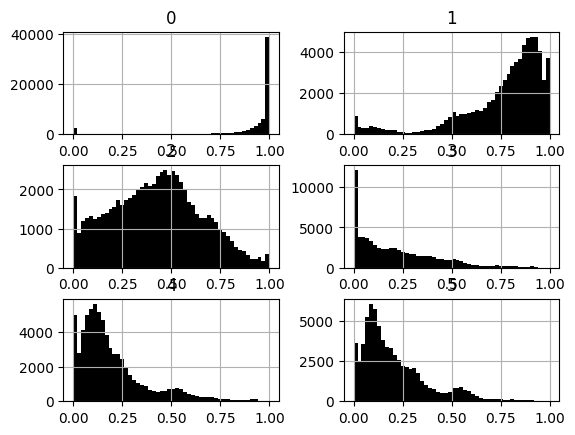

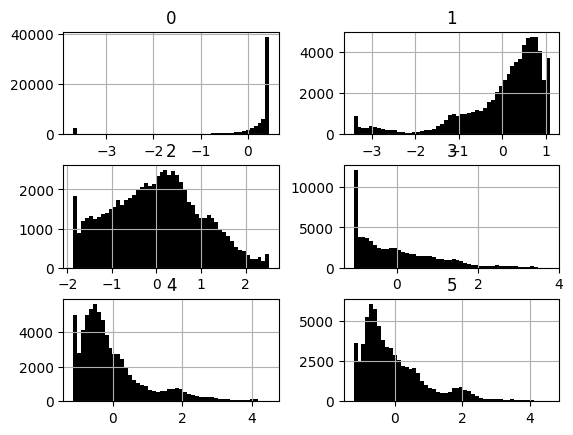

In [6]:
col = x_train.columns[:6]

x_train[col].hist(bins = 50, color='black')
plt.show()

x_ready_df = pd.DataFrame(x_ready, columns=x_train.columns)
x_ready_df[col].hist(bins = 50, color='black')
plt.show()

In [7]:
print("Before:")
print(x_train.iloc[:, :3].mean(), x_train.iloc[:, :3].std())

print("After:")
print(x_ready_df.iloc[:, :3].mean(), x_ready_df.iloc[:, :3].std())

Before:
0    0.890508
1    0.758111
2    0.424135
dtype: float64 0    0.240717
1    0.221705
2    0.227413
dtype: float64
After:
0    3.246201e-18
1    1.378621e-16
2   -4.970746e-17
dtype: float64 0    1.000007
1    1.000007
2    1.000007
dtype: float64


In [8]:
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000, # wydawalo warning na 100, ze nie znalazlo plateau
        class_weight='balanced' # bo mamy dyzbalans klasów
    )),
])

sgd_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        class_weight='balanced',
        loss="log_loss" # domyslnie loss="hinge"
    )),
])

forest_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
    )),
])

start_time = time.time()
log_reg.fit(x_train, y_train)
log_pred = log_reg.predict(x_train)
log_proba = log_reg.predict_proba(x_train) # dla nll
end_time = time.time()
print("Czas log_reg: ", end_time - start_time)

start_time = time.time()
sgd_class.fit(x_train, y_train)
sgd_pred = sgd_class.predict(x_train)
sgd_proba = sgd_class.predict_proba(x_train)
end_time = time.time()
print("Czas sgd_class: ", end_time - start_time)

start_time = time.time()
forest_class.fit(x_train, y_train)
forest_pred = forest_class.predict(x_train)
forest_proba = forest_class.predict_proba(x_train)
end_time = time.time()
print("Czas forest_class: ", end_time - start_time)

Czas log_reg:  114.88600063323975
Czas sgd_class:  19.6661479473114
Czas forest_class:  112.11627984046936


In [9]:
print("NLL dla LogisticRegression: ", log_loss(y_train, log_proba))
print("NLL dla SGDClassifier: ", log_loss(y_train, sgd_proba))
print("NLL dla RandomForestClassifier: ", log_loss(y_train, forest_proba))

NLL dla LogisticRegression:  0.8548267249841408
NLL dla SGDClassifier:  0.43786294040916623
NLL dla RandomForestClassifier:  0.02167428847159826


Number of normal:  57977
Number of supraventricular ectopic beat:  1778
Number of ventricular ectopic beat:  4630
Number of fusion beat:  513
Number of nieokreślone / paced beat:  5145

Dla LogisticRegression
Confusion Matrix:



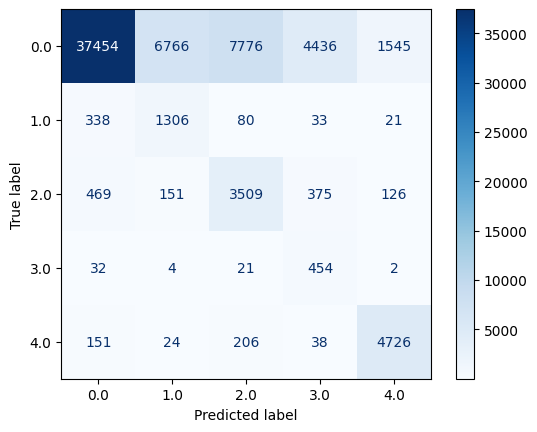

makro-F1 score:  0.4884971097442534
Dla SGDClassifier
Confusion Matrix:



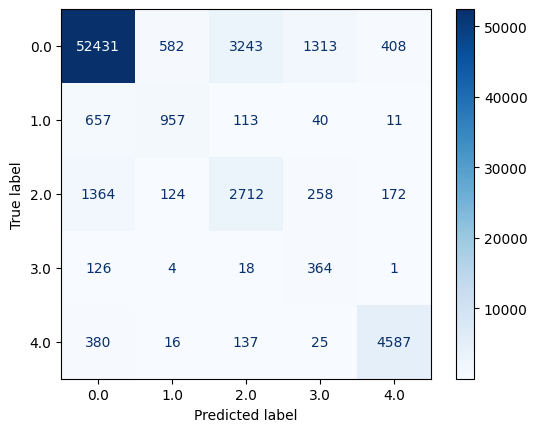

makro-F1 score:  0.6319216140641671
Dla RandomForestClassifier
Confusion Matrix:



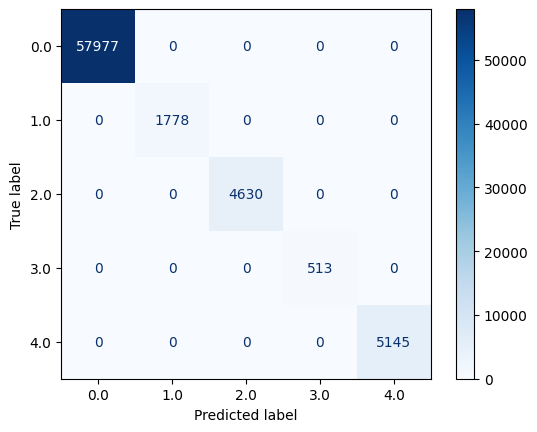

makro-F1 score:  1.0
Dla RandomForestClassifier na walidacyjnym
Confusion Matrix:



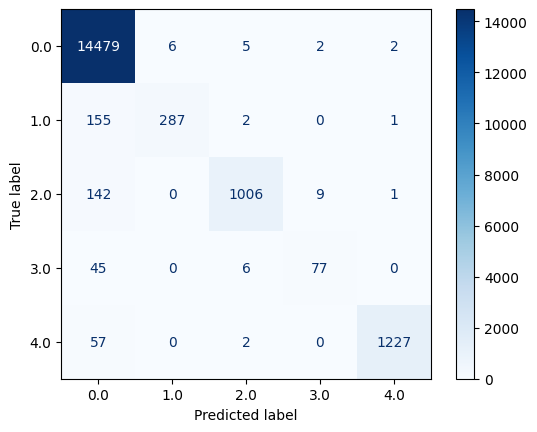

makro-F1 score:  0.8749950451985795


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
classes = np.unique(y_train)

print("Number of normal: ", (y_train == 0).sum())
print("Number of supraventricular ectopic beat: ", (y_train == 1).sum())
print("Number of ventricular ectopic beat: ", (y_train == 2).sum())
print("Number of fusion beat: ", (y_train == 3).sum())
print("Number of nieokreślone / paced beat: ", (y_train == 4).sum())

print("\nDla LogisticRegression")
print("Confusion Matrix:\n")
log_reg_cm = confusion_matrix(y_train, log_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=log_reg_cm, display_labels=classes)
disp1.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, log_pred, average='macro'))

print("Dla SGDClassifier")
print("Confusion Matrix:\n")
sgd_cm = confusion_matrix(y_train, sgd_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=sgd_cm, display_labels=classes)
disp2.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, sgd_pred, average='macro'))

print("Dla RandomForestClassifier")
print("Confusion Matrix:\n")
forest_cm = confusion_matrix(y_train, forest_pred)
disp3 = ConfusionMatrixDisplay(confusion_matrix=forest_cm, display_labels=classes)
disp3.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, forest_pred, average='macro'))

forest_pred_val  = forest_class.predict(x_val)
print("Dla RandomForestClassifier na walidacyjnym") # dla sprawdzenia
print("Confusion Matrix:\n")
forest_cm_2 = confusion_matrix(y_val, forest_pred_val)
disp4 = ConfusionMatrixDisplay(confusion_matrix=forest_cm_2, display_labels=classes)
disp4.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_val, forest_pred_val, average='macro'))

In [12]:
# Druga czesc(Second part):

# Deep Learning using PyTorch — 1D-CNN for MIT-BIH (187 points, 5 classes)

# I have addded these(compared to my previous version):
# 1)per-sample z-score normalization (no leakage)
# 2)capped class weights to reduce "over-predicting" rare class F

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Basic definitions for model training
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# jesli mamy mozliwosc, trenujemy na GPU, inaczej CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

def to_numpy(x):

    if hasattr(x, "values"):  #pandas
        return x.values
    return np.asarray(x)

# train and test sets

x_train = to_numpy(x_train).astype(np.float32)
y_train = to_numpy(y_train).astype(np.int64)

x_val = to_numpy(x_val).astype(np.float32)
y_val = to_numpy(y_val).astype(np.int64)

x_test = to_numpy(x_test).astype(np.float32)
y_test = to_numpy(y_test).astype(np.int64)

# Robimy normalizacje per sample, wazne w kontekscie ECG

def zscore_per_sample(X, eps=1e-8):

    mu = X.mean(axis=1, keepdims=True)


    sd = X.std(axis=1, keepdims=True)
    return (X - mu) / (sd + eps)

# applying
x_train = zscore_per_sample(x_train)
x_val   = zscore_per_sample(x_val)
x_test  = zscore_per_sample(x_test)

class ECGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.from_numpy(X)  # (N, 187)
        self.y = torch.from_numpy(y)  # (N,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):

        x = self.X[idx].unsqueeze(0)  # (1, 187) for Conv1d: (C, L)
        y = self.y[idx]
        return x, y



train_ds = ECGDataset(x_train, y_train)
val_ds   = ECGDataset(x_val, y_val)
test_ds  = ECGDataset(x_test, y_test)


BATCH_SIZE = 256 # rozmiar danych wejsciowych (batch size)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Wagi klas (class weights - imbalance)

num_classes = 5
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)


inv = 1.0 / np.maximum(counts, 1.0)
weights = inv / inv.sum() * num_classes

# Cap weights to avoid extreme bias toward rare class F
#Mozemy je tuningowac, ale to sa defaultowe

W_MIN, W_MAX = 0.10, 2.00

weights_capped = np.clip(weights, W_MIN, W_MAX).astype(np.float32)

class_weights = torch.tensor(weights_capped, dtype=torch.float32, device=device)

# Printing information about this part
print("Class counts:", counts)
print("Raw class weights:", weights)
print("Capped class weights:", weights_capped)

# Model: simple, but also strong 1D-CNN
class ECG_CNN(nn.Module):

    def __init__(self, n_classes=5):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32),
            nn.ReLU(), nn.MaxPool1d(2),  # 187 -> 93

            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),
            nn.ReLU(), nn.MaxPool1d(2),  # 93 -> 46

            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 46 -> 23
        )

        self.classifier = nn.Sequential(
            nn.Flatten(), # 128*23
            nn.Dropout(0.3),
            nn.Linear(128 * 23, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ECG_CNN(n_classes=num_classes).to(device)

# Training
criterion = nn.CrossEntropyLoss(weight=class_weights) # Wykorzystujemy cross-entropy jako loss-function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

# Evaluating macro-F1
@torch.no_grad()

def eval_loader(model, loader):

    model.eval()

    all_preds = []
    all_true = []

    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)

        loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)

        total_n += yb.size(0)


        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())

        all_true.append(yb.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    avg_loss = total_loss / max(total_n, 1)

    return avg_loss, macro_f1, y_true, y_pred

def train_one_epoch(model, loader):

    model.train()
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device)


        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)

        total_n += yb.size(0)

    return total_loss / max(total_n, 1)

# Early stopping (np. jesli loss sie nie zmniejsza) (ex. if loss is not reducing after concrete am. of epochs)

EPOCHS = 25

PATIENCE = 5

best_val_f1 = -1.0
best_state = None

pat_cnt = 0

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader)

    val_loss, val_f1, _, _ = eval_loader(model, val_loader)

    scheduler.step(val_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | "f"val_loss={val_loss:.4f} | val_macroF1={val_f1:.4f} | lr={current_lr:.2e}")

    if val_f1 > best_val_f1 + 1e-4:

        best_val_f1 = val_f1

        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        pat_cnt = 0


    else:
        pat_cnt += 1
        if pat_cnt >= PATIENCE:
            print(f"Early stopping: no improvement for {PATIENCE} epochs.")
            break

# Loading the best model
if best_state is not None:

    model.load_state_dict(best_state)


print("Best val macro-F1:", best_val_f1)

# Test evaluation

test_loss, test_f1, y_true_test, y_pred_test = eval_loader(model, test_loader)
print(f"Test loss={test_loss:.4f} | Test macro-F1={test_f1:.4f}")

# confusion matrix = which classes are correctly identified and which are not
cm = confusion_matrix(y_true_test, y_pred_test, labels=list(range(num_classes)))
print("Confusion Matrix (rows=true, cols=pred):\n", cm)

print("\nClassification report:")
print(classification_report(y_true_test, y_pred_test, digits=4))

print("Autorzy: Artsiom Tsiushnikau & Diemid Rybchenko | Authors: Artsiom Tsiushnikau & Diemid Rybchenko")


Device: cpu
Class counts: [57977.  1778.  4630.   513.  5145.]
Raw class weights: [0.02934027 0.9567273  0.3673998  3.3159087  0.3306241 ]
Capped class weights: [0.1       0.9567273 0.3673998 2.        0.3306241]
Epoch 01/25 | train_loss=0.4293 | val_loss=0.2838 | val_macroF1=0.8570 | lr=1.00e-03
Epoch 02/25 | train_loss=0.2607 | val_loss=0.2298 | val_macroF1=0.8478 | lr=1.00e-03
Epoch 03/25 | train_loss=0.2203 | val_loss=0.2216 | val_macroF1=0.8767 | lr=1.00e-03
Epoch 04/25 | train_loss=0.1884 | val_loss=0.1929 | val_macroF1=0.8371 | lr=1.00e-03
Epoch 05/25 | train_loss=0.1663 | val_loss=0.1763 | val_macroF1=0.8508 | lr=1.00e-03
Epoch 06/25 | train_loss=0.1527 | val_loss=0.1442 | val_macroF1=0.8743 | lr=5.00e-04
Epoch 07/25 | train_loss=0.1183 | val_loss=0.1327 | val_macroF1=0.8618 | lr=5.00e-04
Epoch 08/25 | train_loss=0.1050 | val_loss=0.1341 | val_macroF1=0.8911 | lr=5.00e-04
Epoch 09/25 | train_loss=0.0984 | val_loss=0.1348 | val_macroF1=0.8841 | lr=5.00e-04
Epoch 10/25 | train_lo